<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/practicals/Practical_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 1 -- RC circuit, Numerical Integration methods, Rate based models

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# @title Make plots nicer  -- Execute this cell
def mystyle():
  """
  Create custom plotting style.

  Returns
  -------
  my_style : dict
      Dictionary with matplotlib parameters.

  """
  # color pallette
  style = {
      # Use LaTeX to write all text
      "text.usetex": False,
      "font.family": "DejaVu Sans",
      "font.weight": "bold",
      # Use 16pt font in plots, to match 16pt font in document
      "axes.labelsize": 16,
      "axes.titlesize": 20,
      "font.size": 16,
      # Make the legend/label fonts a little smaller
      "legend.fontsize": 14,
      "xtick.labelsize": 14,
      "ytick.labelsize": 14,
      "axes.linewidth": 2.5,
      "lines.markersize": 10.0,
      "lines.linewidth": 2.5,
      "xtick.major.width": 2.2,
      "ytick.major.width": 2.2,
      "axes.labelweight": "bold",
      "axes.spines.right": False,
      "axes.spines.top": False
  }

  return style


plt.style.use("seaborn-colorblind")
plt.rcParams.update(mystyle())

## RC circuit

Electric circuit of the membrane patch

\begin{align}
C_m \frac{dV_m}{dt} &= -\frac{V_m}{R_m} + I_{ext} \\
R_m C_m \frac{dV_m}{dt} &= -V_m + I_{ext} R_m \\
\tau_m \frac{dV_m}{dt} &= -V_m + V_{\infty}
\end{align}

where $\tau_m = C_m R_m$ denotes the membrane time constant, and $V_{\infty}=I_{ext} R_m$ is the voltage steady-state, i.e., where the derivative is zero.

### Analytical solution

\begin{align}
\tau_m \frac{dV_m}{dt} &= -V_m + V_{\infty} \\
\tau_m \frac{dV_m}{dt} &= -(V_m - V_{\infty}) \\
\frac{dV_m}{(V_m - V_{\infty})} &= -\frac{dt}{\tau_m} \\
\end{align}

Integrate both sides of the equation:

\begin{align}
\int \frac{1}{(V_m - V_{\infty})}dV_m &= \int -\frac{1}{\tau_m}dt \\
\text{ln} |V_m - V_{\infty}| &= -\frac{t}{\tau_m} + c, c \in \mathbb{R}
\end{align}

Then, we exponentiate both parts to remove the logarithm, i.e., $\text{ln}(\cdot)$

\begin{align}
e^{\text{ln} |V_m - V_{\infty}|} &= e^{-\frac{t}{\tau_m} + c} \\
|V_m - V_{\infty}| &= e^{-\frac{t}{\tau_m}}e^{c} \\
V_m - V_{\infty} &= \pm e^{c} e^{-\frac{t}{\tau_m}}\\
\end{align}

Let $k = \pm e^{c}, k \in \mathbb{R}$

\begin{align}
V_m - V_{\infty} &= k e^{-\frac{t}{\tau_m}}\\
\end{align}

At $t=0$, $V_m$ is zero, $V_m=0$

\begin{align}
V_m(t=0) - V_{\infty} &= k e^{-\frac{t=0}{\tau_m}}\\
k &= - V_{\infty} 
\end{align}

Thus, the solution is:

\begin{align}
V_m(t) - V_{\infty} &= - V_{\infty} e^{-\frac{t=0}{\tau_m}}\\
V_m(t) &= V_{\infty} \left( 1-e^{-\frac{t}{\tau_m}} \right)
\end{align}

At $t=\tau_m$, $V_m$ is $V_m = V_\infty (1-e^{-1})$, $1-e^{-1} \approx 0.63$

So, the membrane time constant denotes the time needed for voltage to reach the 63% of its steady state-value.

### Analytical solution - Euler Method

\begin{align}
\tau_m \frac{dV_m}{dt} &= -(V_m - V_{\infty}) \\
\frac{dV_m}{dt} &= -\frac{(V_m - V_{\infty})}{\tau_m}
\end{align}

Euler method gives:

\begin{align}
V_m[n+1] = V_m[n] + dt \cdot \frac{dV_m}{dt}|_n, n^{th} step \\
\end{align}

$N_{steps} = T / dt$, $T$ is the total simulation time.

---
## Euler method -- Simple example

Let us model the exponential function, i.e., $f(t) = e^{-t}$. We know that its derivative with respect to time is

\begin{equation}
\frac{df}{dt} = -e^{-t}
\end{equation}

Mean Squared Error (MSE) is: 0.0020743


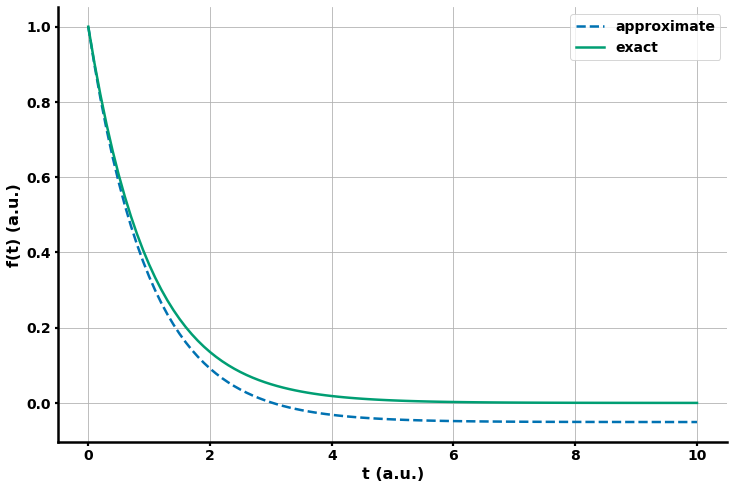

In [3]:
T = 10  # time points (a.u.)
dt = 0.1  # integration step (a.u.)
N = int(T/dt)  # number of steps

# t = np.arange(0, T + dt, dt)  # alternatively we can use np.linspace
t = np.linspace(0, T, N+1)
f_exact = np.exp(-t)

f_approx = np.zeros((N + 1, ))
f_approx[0] = 1  # initial condition
for n in range(N):
  deriv = -np.exp(-n*dt)
  f_approx[n+1] = f_approx[n] + dt*deriv


error = np.mean(f_exact - f_approx)**2
print(f"Mean Squared Error (MSE) is: {np.round(error, 7)}")

plt.figure(figsize=(12, 8))
plt.plot(t, f_approx, label='approximate', linestyle='dashed')
plt.plot(t, f_exact, label='exact')
plt.xlabel('t (a.u.)')
plt.ylabel('f(t) (a.u.)')
plt.legend()
plt.grid()
plt.show()

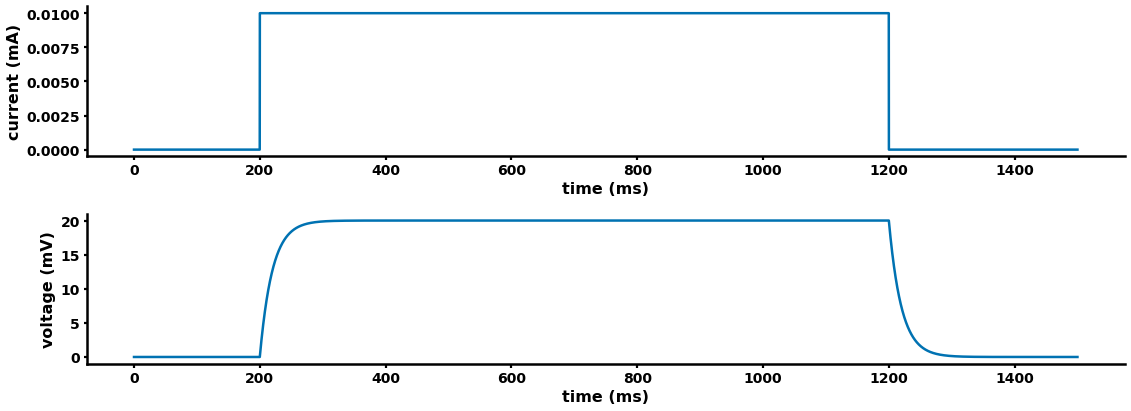

In [4]:
# Euler method

Rm = 2000  # Ohm

tau = 20  # ms
dt = 0.1  # ms
T = 1500
steps = int(T/dt)
time = np.linspace(0, T, steps+1)

Vm = np.zeros((steps + 1, ))  # empty list
t1 = 200  # stimulus onset in ms
t2 = 1200  # stiumulus withdraw in ms

# External current as a vector
Iext = np.zeros((steps+1, ))
Iext[int(t1/dt):int(t2/dt)+1] = 0.01

for n in range(steps):
  # After t1 ms and up unitl t2 ms add the external current
  #if n*dt < t1 or n*dt > t2:
  #  Iext = 0
  #else:
  #  Iext = 0.01  # mA

  Vss = Iext[n] * Rm  # mV
  dVdt = -(Vm[n]-Vss)/tau
  Vm[n+1] = Vm[n] + dt*dVdt

plt.figure(figsize=(16, 6))
plt.subplot(2, 1, 1)
plt.plot(time, Iext)
plt.xlabel('time (ms)')
plt.ylabel('current (mA)')
plt.subplot(2, 1, 2)
plt.plot(time, Vm)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.tight_layout()
plt.show()

---
## Rate-base models

Example 1: A simple model

\begin{equation}
\tau \frac{d\textbf{r}}{dt} = -\textbf{r} + F(I_{ext} + J\textbf{r})
\end{equation}

where $\textbf{r} \in \mathbb{R}^{n \times 1}, J \in \mathbb{R}^{n \times n}$

In [5]:
def sigmoid(z, theta=0):
  return 1/(1+np.exp(-(z-theta)))

In [14]:
sigmoid(z=0, theta=2)

0.11920292202211755

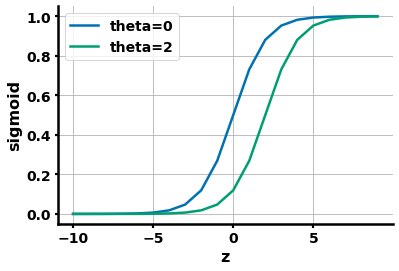

In [15]:
z = np.arange(-10, 10, 1)

plt.figure()
plt.plot(z, sigmoid(z), label='theta=0')
plt.plot(z, sigmoid(z, theta=2), label='theta=2')
plt.xlabel('z')
plt.ylabel('sigmoid')
plt.grid()
plt.legend()
plt.show()

In [29]:
np.random.seed(2021)
N = 12  # number of neurons
J = -np.random.rand(N, N)*2  # Weight matrix
np.fill_diagonal(J, 0)  # remove autopses
print(J)

[[ 0.         -1.46673872 -0.27789431 -0.62534617 -1.99448656 -0.25632475
  -0.35798621 -1.50585086 -1.32432103 -1.56862026 -0.19378879 -0.11714257]
 [-1.92479198  0.         -0.17325992 -1.12254473 -1.23304942 -1.92768605
  -1.14860859 -0.7423217  -0.90429049 -0.4037005  -1.13861024 -0.39019195]
 [-1.16740803 -0.95262695  0.         -1.64619727 -1.46445005 -0.13811255
  -1.34425787 -1.28696961 -1.65602874 -0.40893879 -1.23497791 -1.23540202]
 [-0.60213724 -1.74348117 -1.17930816  0.         -0.88446447 -0.25263537
  -1.0176618  -0.86357237 -1.83187913 -1.41803128 -1.78131077 -1.17777122]
 [-1.27365985 -0.68441787 -1.64758237 -0.61030154  0.         -0.40264532
  -0.5303299  -1.30184751 -0.30922962 -0.777399   -1.29522829 -1.69659823]
 [-0.127673   -0.82888236 -0.6644885  -1.44264195 -0.9476946   0.
  -0.1817338  -1.74911364 -1.55395372 -1.54313284 -0.12620666 -1.18887697]
 [-1.58498947 -0.54826736 -0.74203963 -1.70622908 -1.35745784 -1.50875493
   0.         -0.64179747 -0.74459274 -0

In [34]:
np.random.seed(2021)
T = 1000  # ms
dt = 0.1  # ms
steps = int(T/dt)
t = np.linspace(0, T, steps+1)
Iext = 0.1
tau = 22  # ms
r = np.zeros((steps + 1, N))
r[0,:] = 0.01
for n in range(steps):
  z1 = Iext + J@r[n,:] + np.random.rand(1, N)
  deriv = (-r[n,:] + sigmoid(z1, theta=2))/tau
  r[n+1, :] = r[n, :] + dt*deriv

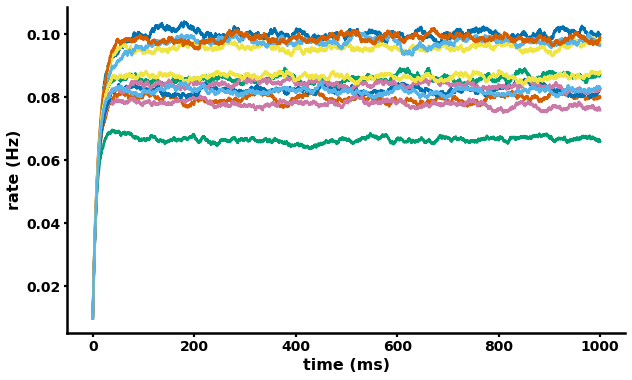

In [36]:
plt.figure(figsize=(10, 6))

for i in range(N):
  plt.plot(t, r[:,i], label=f'neuron {i+1}')

plt.xlabel('time (ms)')
plt.ylabel('rate (Hz)')
#plt.legend()
plt.show()

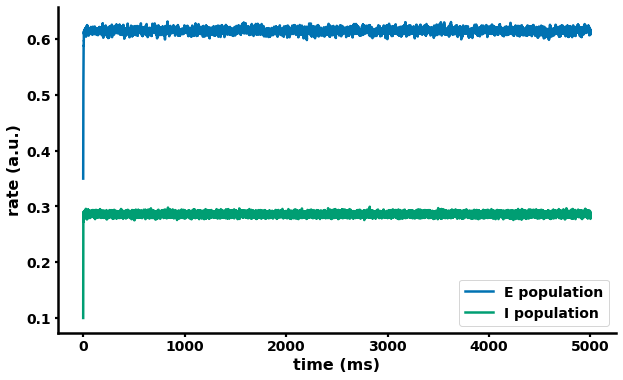

In [47]:
np.random.seed(2021)
dt = 0.1  # ms
T = 5000  # ms
steps = int(T/dt)  # sample points
time = np.linspace(0, T, steps+1)

# preallocation
rE = np.zeros((steps+1, ))
rI = np.zeros((steps+1, ))

# parameters
tauE = 2.0  # ms
tauI = 1.0  # ms
JEE = 1  # From E to E
JEI = 4  # From I to E
JIE = 2  # From E to I
JII = 11  # From I to I
IE = 1  # external current to E population
II = 1  # external current to I population

# Initial conditions
rE[0] = .35
rI[0] = .1

sigma = 0.1  # level of noise
for n in range(steps):
    derivE = (-rE[n] + sigmoid(IE + JEE*rE[n] - JEI*rI[n] + sigma*np.random.randn()))/tauE
    rE[n+1] = rE[n] + dt * derivE

    derivI = (-rI[n] + sigmoid(II + JIE*rE[n] - JII*rI[n] + sigma*np.random.randn()))/tauI
    rI[n+1] = rI[n] + dt * derivI
    
    
plt.figure(figsize=(10, 6))
plt.plot(time, rE, label='E population')
plt.plot(time, rI, label='I population')
plt.xlabel('time (ms)')
plt.ylabel('rate (a.u.)')
plt.legend()
plt.show()

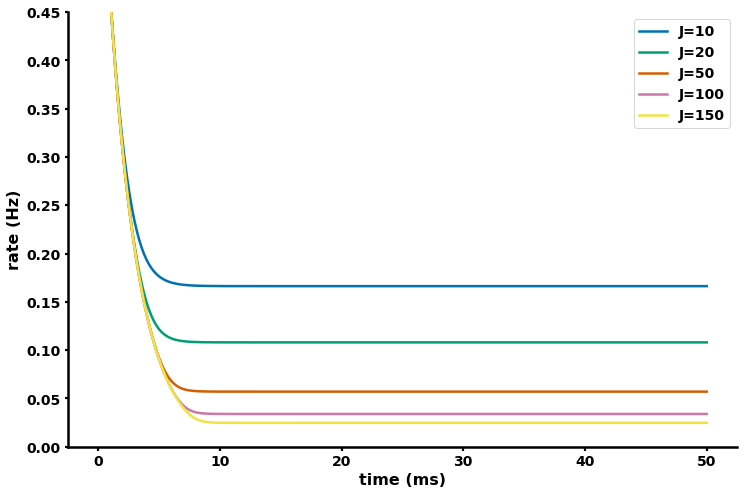

In [51]:
T = 50  # ms
dt = 0.1  # ms
steps = int(T/dt)
t = np.linspace(0, T, steps+1)

Iext = .05
tauI = 2.5
delay = 0.  # ms
D = int(delay/dt)  # for oscillations, steps

plt.figure(figsize=(12, 8))
for i in [10, 20, 50, 100, 150]:
  J_II = i  # Weight matrix
  rI = np.zeros((steps+1, ))
  rI[0] = 0.7
  for n in range(steps):
    n_ = 0 if n-D < 0 else n - D

    deriv = (-rI[n] + sigmoid(Iext - J_II*rI[n_]))/tauI
    rI[n+1] = rI[n] + dt*deriv

  plt.plot(t, rI, label=f"J={J_II}")

plt.legend()
plt.xlabel('time (ms)')
plt.ylabel('rate (Hz)')
plt.ylim([0, 0.45])
plt.show()